In [1]:
#### Other libraries
import sys
import os

import ast
from collections import Counter

import re
import nltk

import numpy as np
import pandas as pd

In [2]:
#### Visualization
sys.path.append('/Users/debr/English-Homer/functions') 
import matplotlib.pyplot as plt
import seaborn as sns

import e_plots as oz      # My custom plots library
import e_chroma as chroma # My Vizualization library

# Set custom output path
nb_id = "Etymology_Six_Modern_B"  
output_path_plots = f"./Etymology_Six_Modern/{nb_id}_plots/"
chroma.set_output_path(output_path_plots)


# Import my functions
import e_nlp_ody as e


* Got some chroma in your soma, Oma!
	 »----> use chroma.save_figure(fig, 'my_plot')
Default output path: ./plots/

* OZ is behind the curtain!
	 »----> eg: oz.plot_etymology_counts(my_df, 'AT_Murray', book_range=1)
Output path set to: ./Etymology_Six_Modern/Etymology_Six_Modern_B_plots/

* The editor is in the house!
	 »----> use e.<func> e.g. nlp = e.NLPPipeline(language='english')

Stopwords customized:
  Added: {'n', 'five', 'nine', 'four', 'three', "'and", "'", 'two', 'eight', 'six', 'ten', 'one', 'seven'}
  Removed: {''}
  Total stopwords: 211
Punctuation customized:
  Keeping: {'', '-'}
  Additional removals: {',\n        "\'",\n        ', '…', "'", '-', '—', '\\'}
  Punctuation to be removed: !"#$%&'()*+,,
        "'",
        -./:;<=>?@[\]^_`{|}~—…


[nltk_data] Downloading package punkt_tab to /Users/debr/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


In [3]:
# Etymologies

etymologypath = '/Users/debr/odysseys_en/word_ety_odysseys.tsv'

etymology_df = pd.read_csv(etymologypath, sep="\t", names=["word", "etymology"], encoding="utf-8")

etymology_df['ety_label'] = etymology_df['etymology'].str.extract(r"\['(\w{3})").astype("category")
#etymology_df.sample(6, random_state=42)

In [4]:
# Odysseys
filepath = '/Users/debr/odysseys_en/Odyssey_Six_Modern.csv'

odysseys_df = pd.read_csv(filepath, sep=",", encoding="utf-8")
odysseys_df = odysseys_df[['translator', 'book_num', 'tokens']]
odysseys_df['translator'] = odysseys_df['translator'].astype("category")
odysseys_df['tokens'] = odysseys_df['tokens'].apply(ast.literal_eval)
e.check_df(odysseys_df)

Mr righteous here has no missing values!

* df columns: Index(['translator', 'book_num', 'tokens'], dtype='object') 

* Shape: (144, 3) 

* Total memory in MB: 2.860675


Origins_of_English_PieChart_2D.svg

Compare the etymological word distribution of 
- "Standard" English 
- Woolf's A Voyage Out
- Odysseys


In [5]:
# Explode tokens column 
odyssey_exploded = odysseys_df.explode("tokens")
# Merge with etymology_df to get ety_label
odyssey_exploded = odyssey_exploded\
                            .merge(etymology_df[['word', 'ety_label']], 
                            left_on='tokens', right_on='word', how='left')

# Group back by translator and book_num to form lists of ety_labels
odysseys_df['ety_labels'] = odyssey_exploded\
                            .groupby(['translator', 'book_num'],
                                      observed=True)['ety_label']\
                                    .apply(list).reset_index(drop=True)

odysseys_df['ety_label_counts'] = odysseys_df['ety_labels'].apply(lambda x: dict(Counter(x)))
odysseys_df.sample(6, random_state=42)

,translator,book_num,tokens,ety_labels,ety_label_counts
117,Wilson,22,"[odysseus, ripped, oﬀ, rags, naked, leapt, upo...","[eng, eng, eng, eng, eng, eng, ang, ang, eng, ...","{'eng': 1244, 'ang': 638, 'cym': 4, 'enm': 343..."
19,AT_Murray,20,"[odysseus, slept, room, upon, undressed, bullo...","[eng, eng, ang, enm, eng, ang, enm, ang, eng, ...","{'eng': 704, 'ang': 421, 'enm': 288, 'lat': 10..."
82,Fagles,11,"[came, ship, water, edge, hauled, launched, su...","[eng, enm, ang, enm, eng, lat, ang, ang, ang, ...","{'eng': 1452, 'enm': 525, 'ang': 726, 'lat': 1..."
97,Wilson,2,"[early, dawn, born, fingers, bloomed, odysseus...","[ang, eng, eng, fra, eng, ang, enm, eng, eng, ...","{'ang': 570, 'eng': 942, 'fra': 16, 'enm': 352..."
56,Lattimore,9,"[resourceful, odysseus, spoke, turn, answered,...","[eng, eng, ang, eng, enm, lat, eng, eng, ang, ...","{'eng': 1274, 'ang': 619, 'enm': 343, 'lat': 1..."
12,AT_Murray,13,"[thus, speak, held, peace, throughout, covered...","[enm, ang, eng, xno, eng, eng, ang, eng, enm, ...","{'enm': 318, 'ang': 404, 'eng': 778, 'xno': 22..."


In [6]:
# # Single book analysis
# oz.plot_etymology_counts(my_df, "Murray", book_range=1)

# # Multiple books
# oz.plot_etymology_counts(my_df, "Murray", book_range=[1, 5, 9])

# # Range of books
# oz.plot_etymology_counts(my_df, "Butler", book_range=(1, 5))

# # Compare translators
# oz.plot_etymology_comparison(my_df, ["Murray", "Butler", "Pope"], book_num=1)

# # Create heatmap visualization
# oz.plot_etymology_heatmap(my_df, "Murray", book_range=(1, 24))

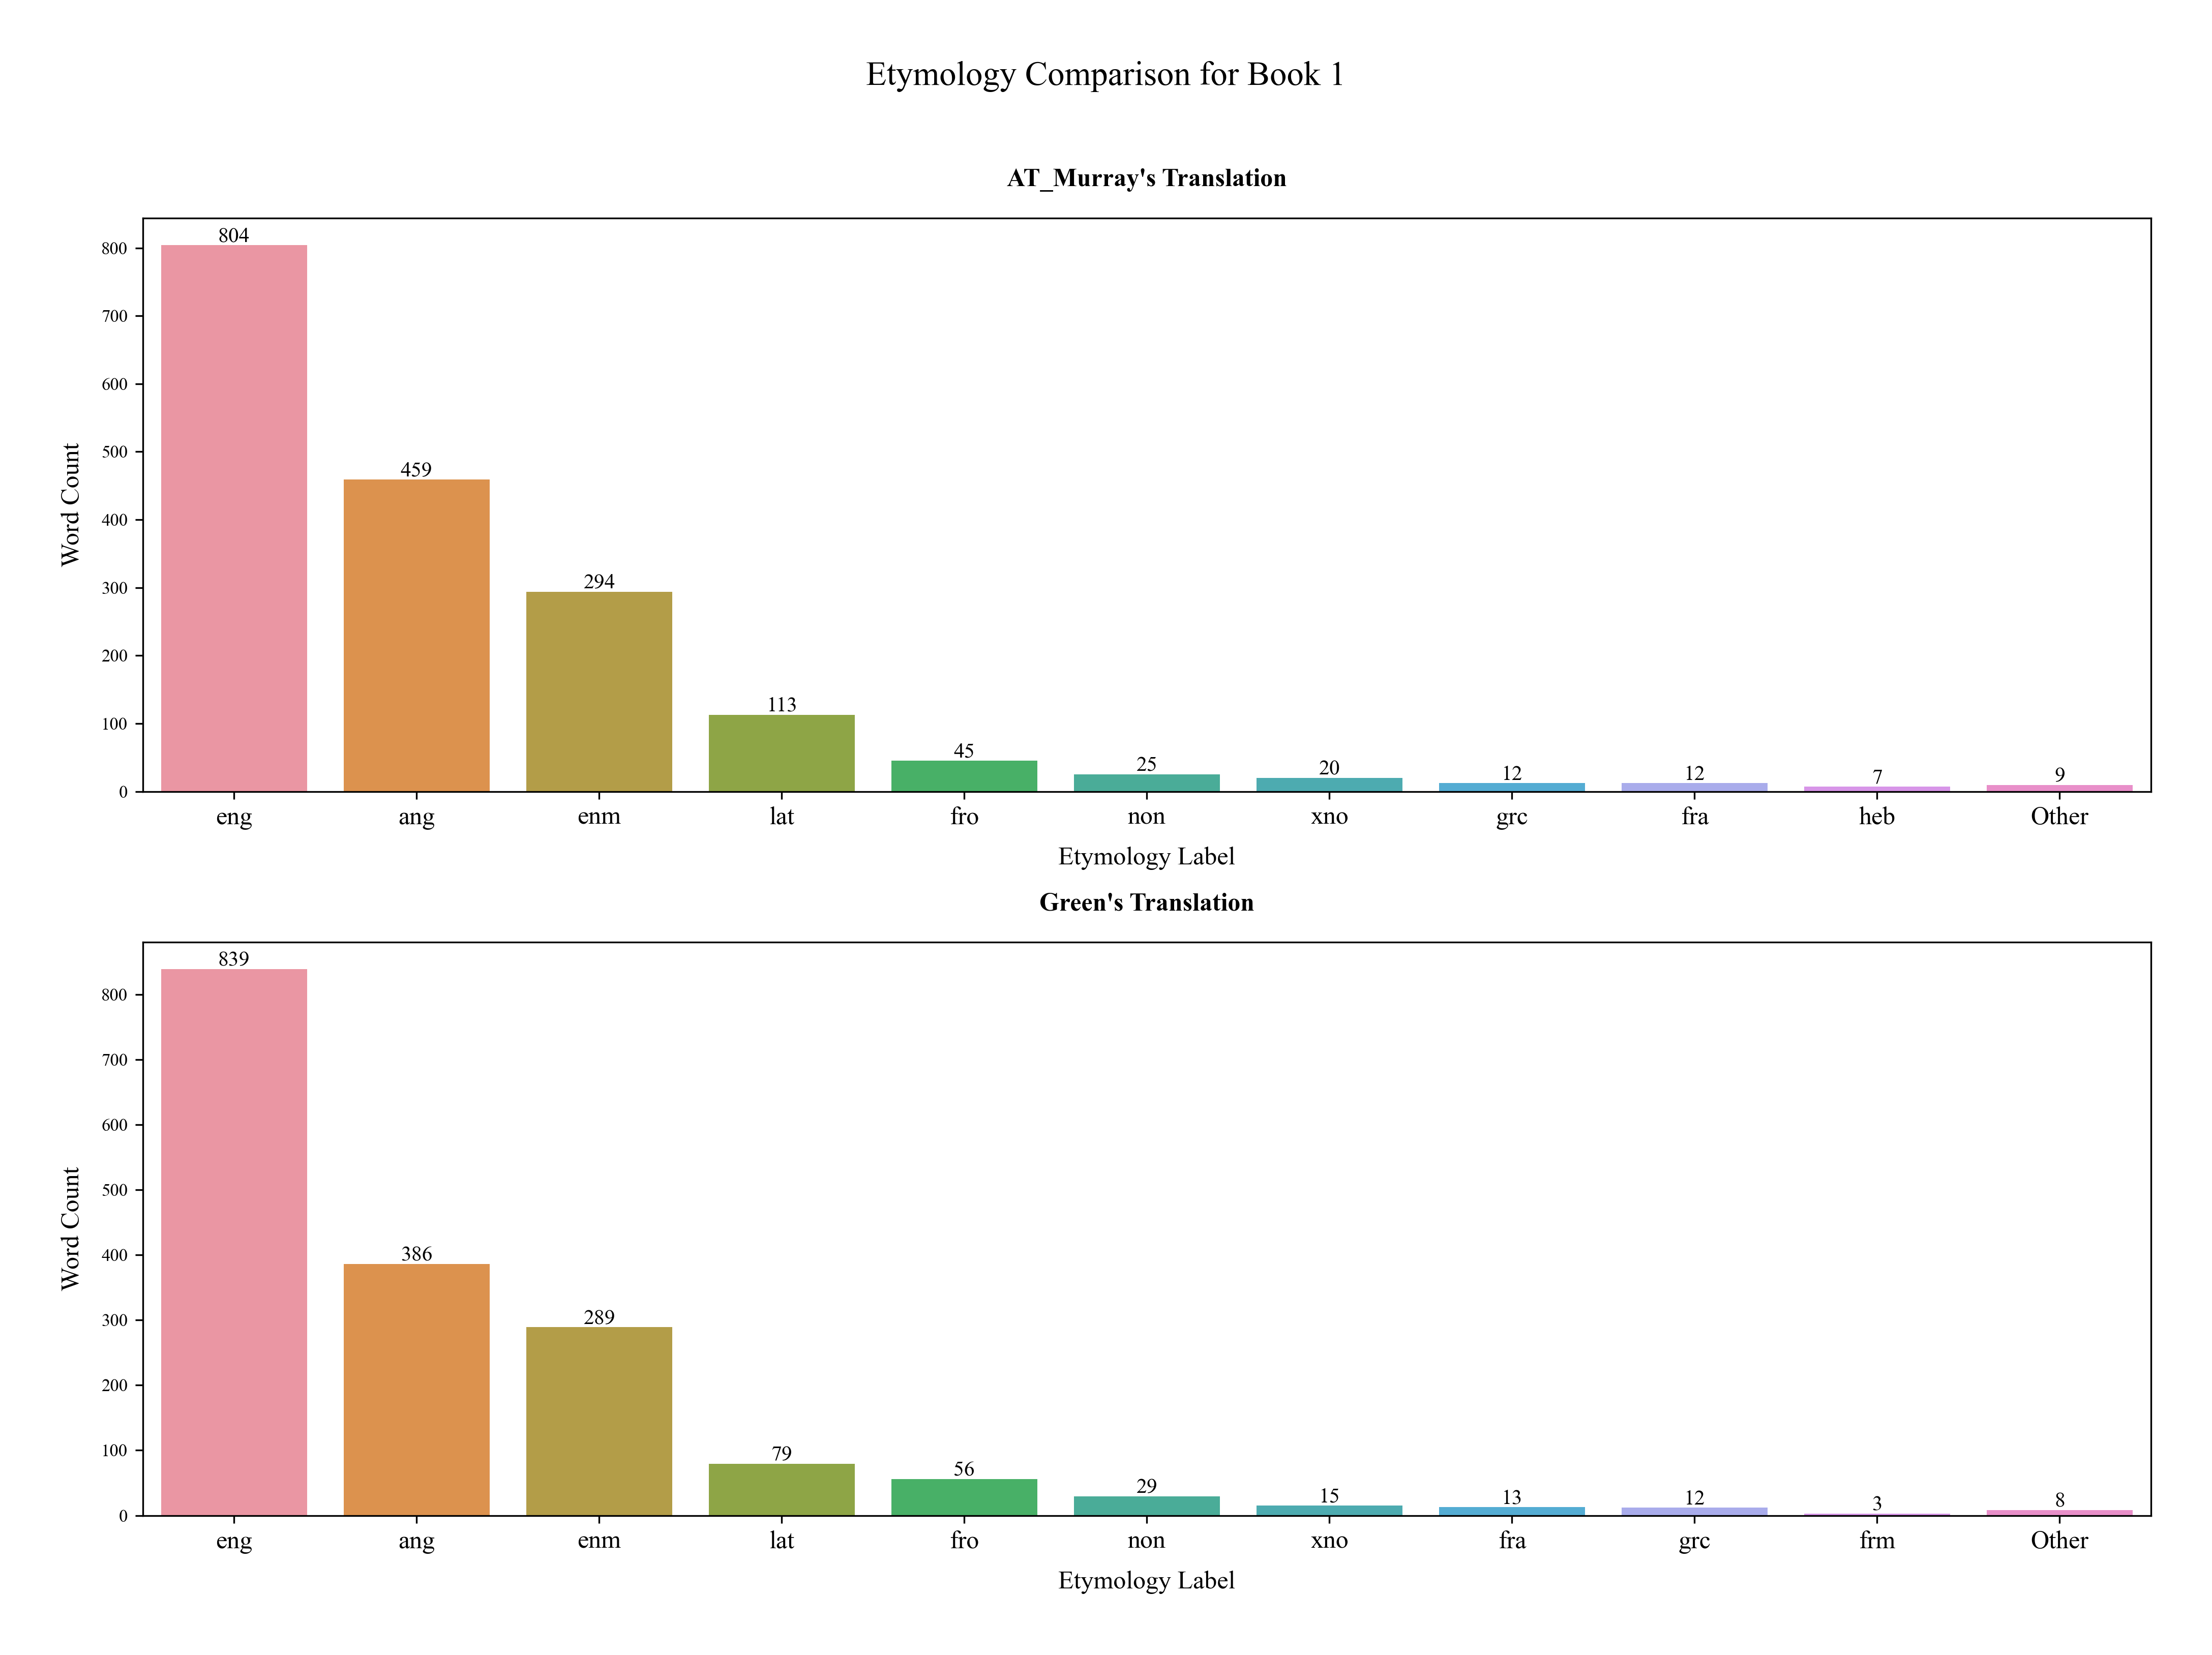

In [7]:
fig = oz.plot_etymology_comparison(odysseys_df, ["AT_Murray", "Green"], book_num=1)
fig.savefig(f"{output_path_plots}/ety_comparison_Murray_Butler_Pope_Book_1.png", dpi=300)


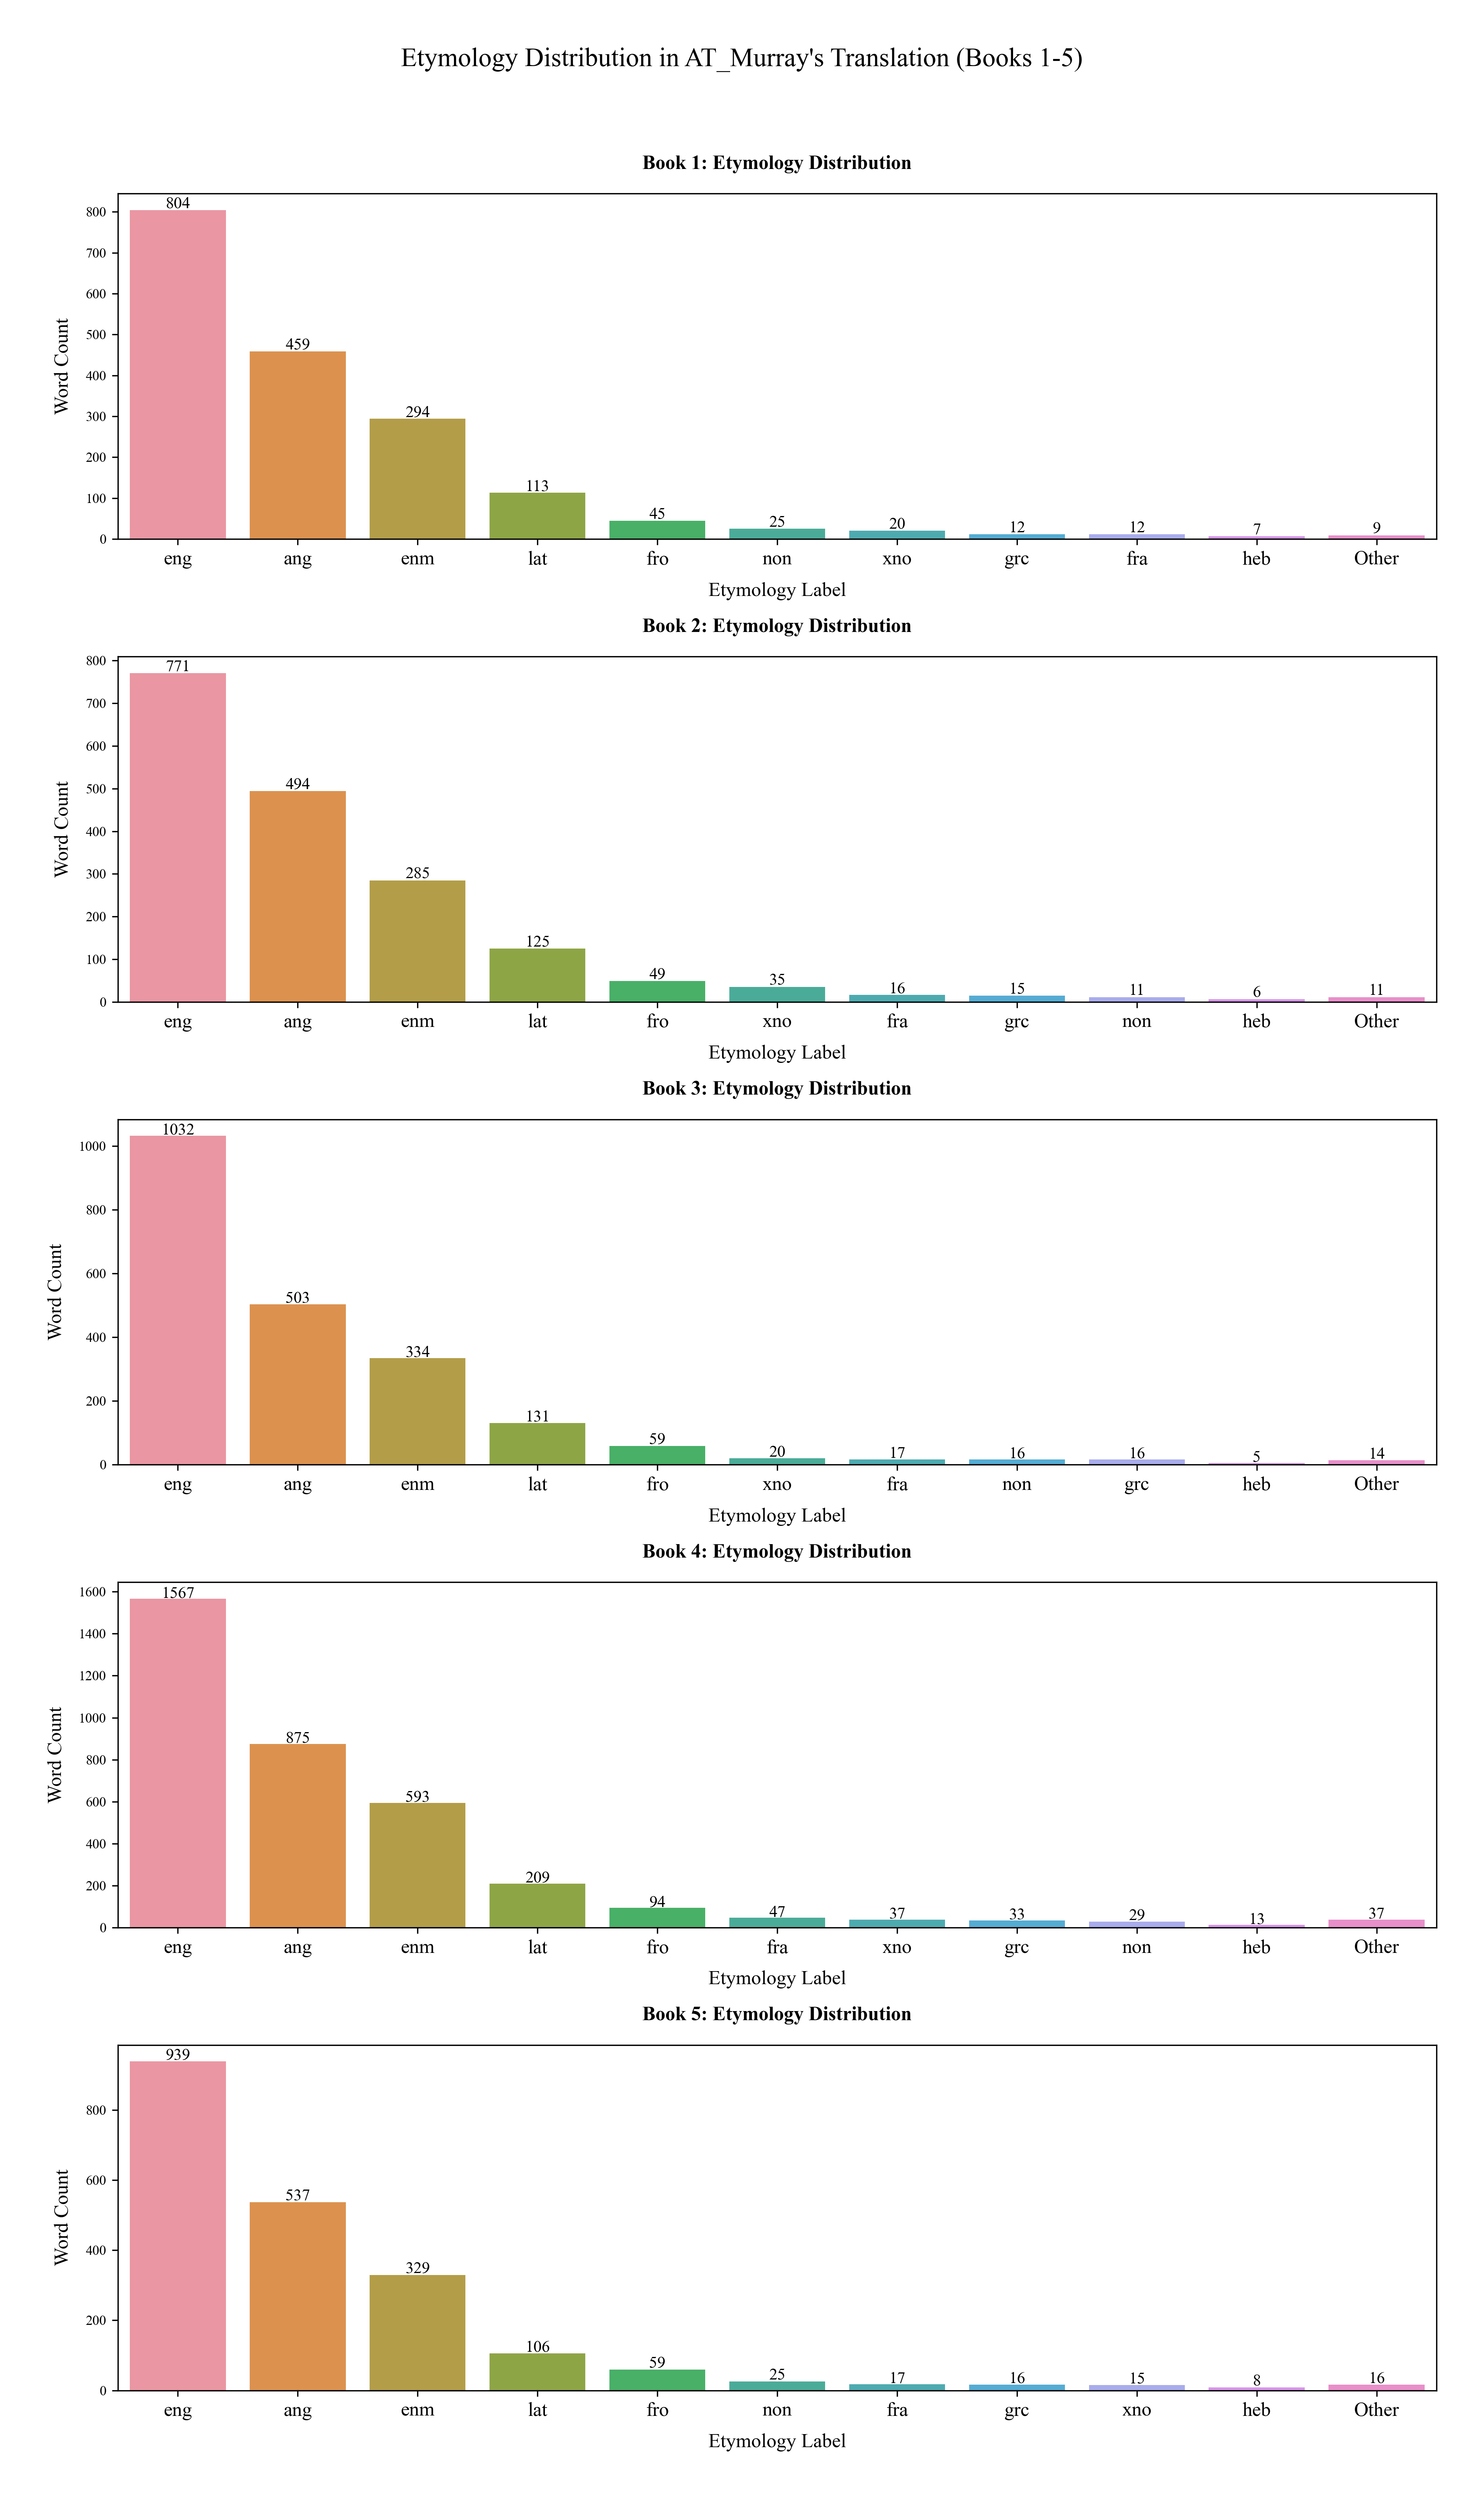

In [8]:
fig = oz.plot_etymology_counts(odysseys_df, "AT_Murray", book_range=(1, 5))

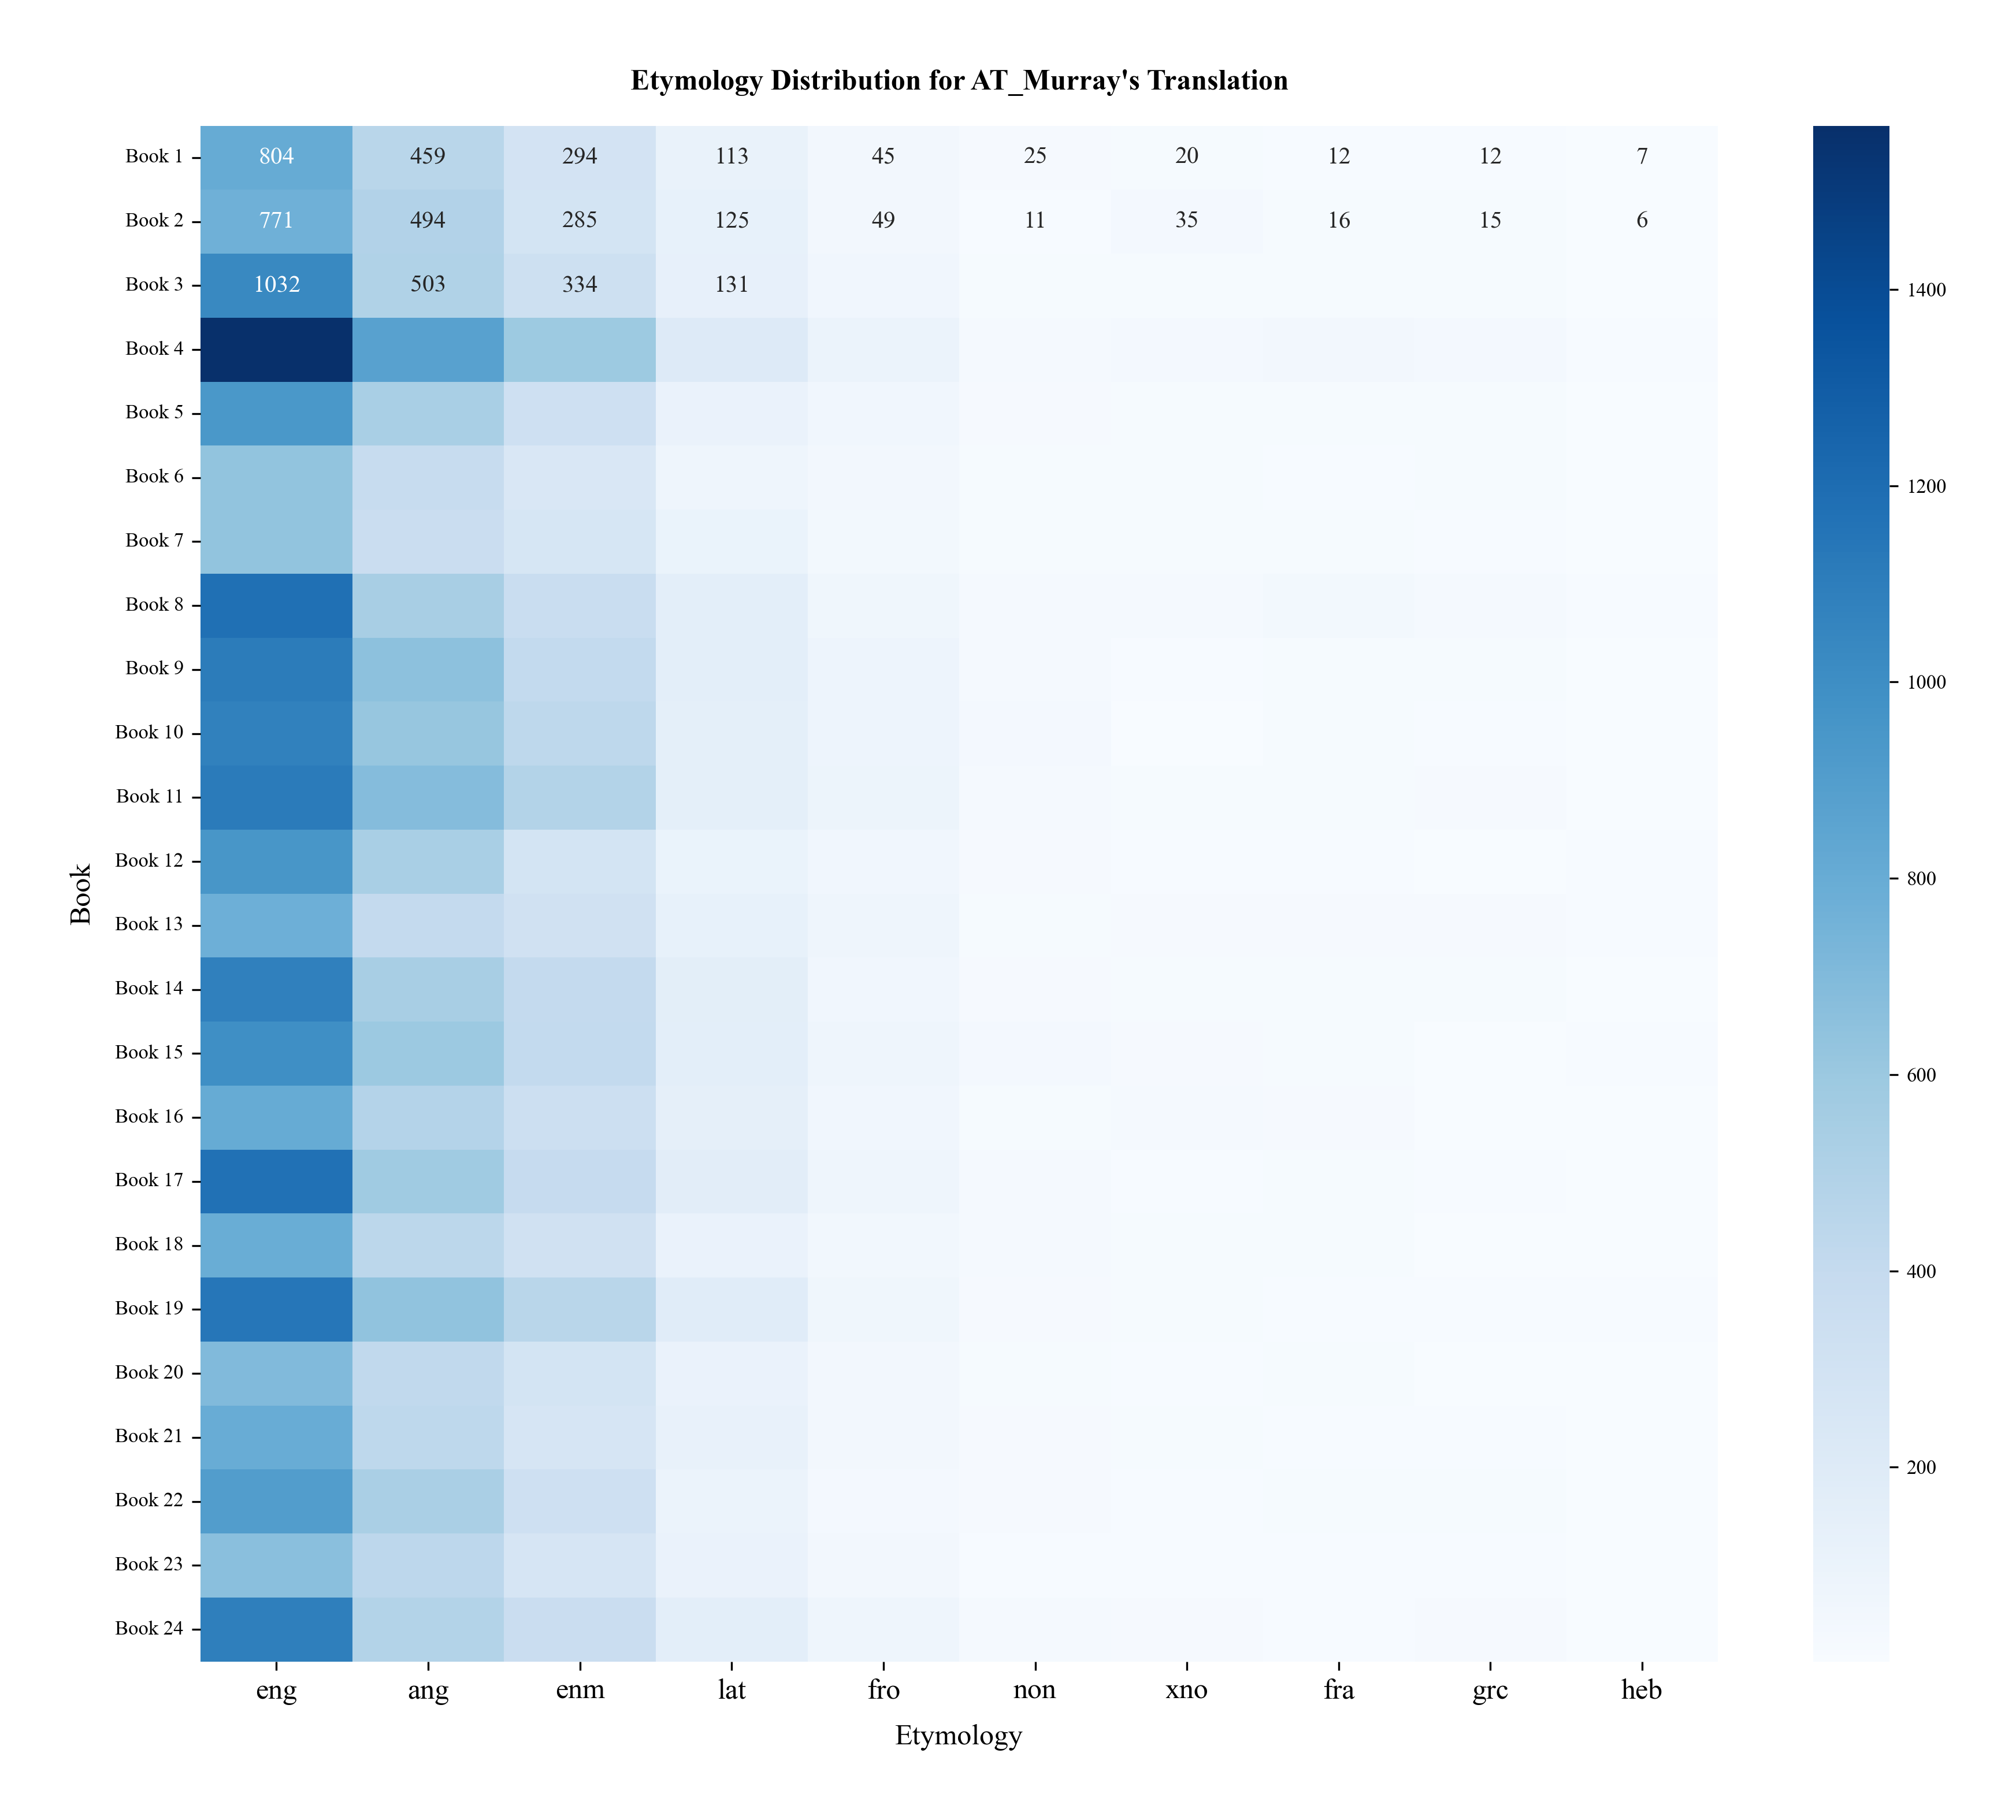

In [9]:
fig = oz.plot_etymology_heatmap(odysseys_df, "AT_Murray", book_range=(1, 24))

In [10]:
at_murray = odysseys_df[odysseys_df['translator'] == 'AT_Murray']
#at_murray_count = at_murray['ety_label_counts'].sum()
e.check_df(at_murray)

Mr righteous here has no missing values!

* df columns: Index(['translator', 'book_num', 'tokens', 'ety_labels', 'ety_label_counts'], dtype='object') 

* Shape: (24, 5) 

* Total memory in MB: 0.863103


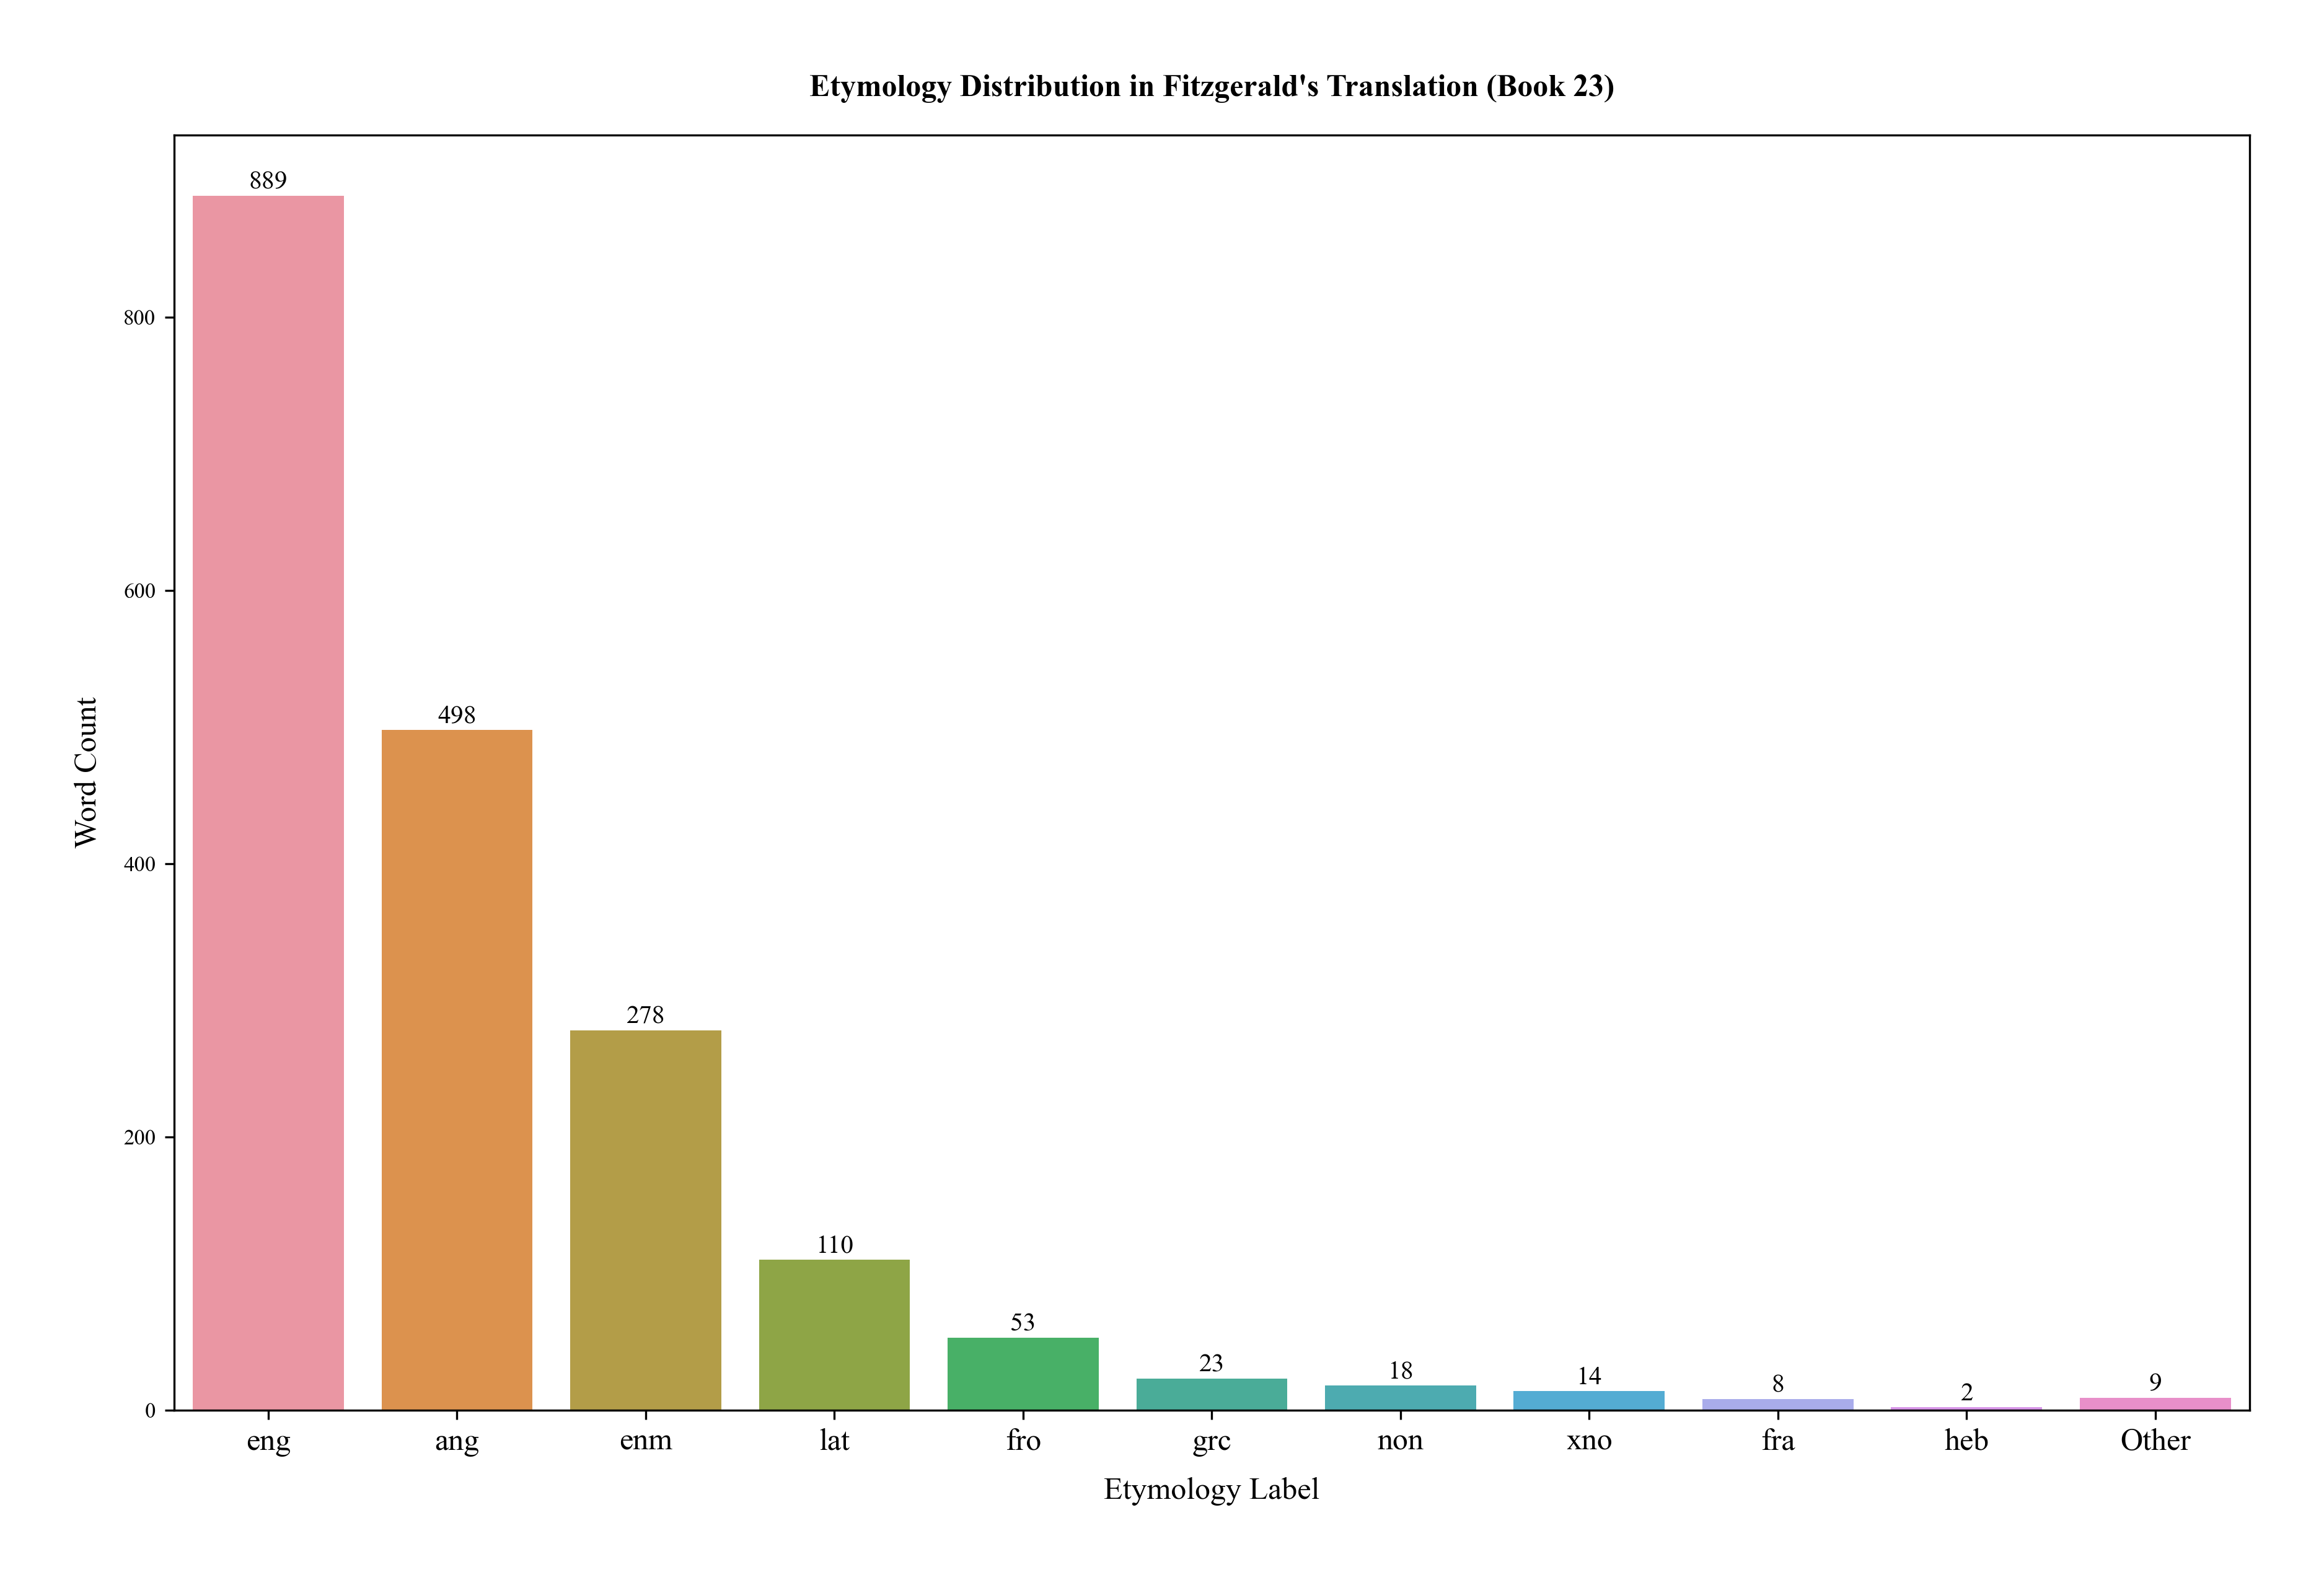

In [12]:
Fitzgerald = odysseys_df[odysseys_df['translator'] == 'Fitzgerald']
plot_etymology_counts(Fitzgerald, translator_name='Fitzgerald', book_num=23, top_n=10)

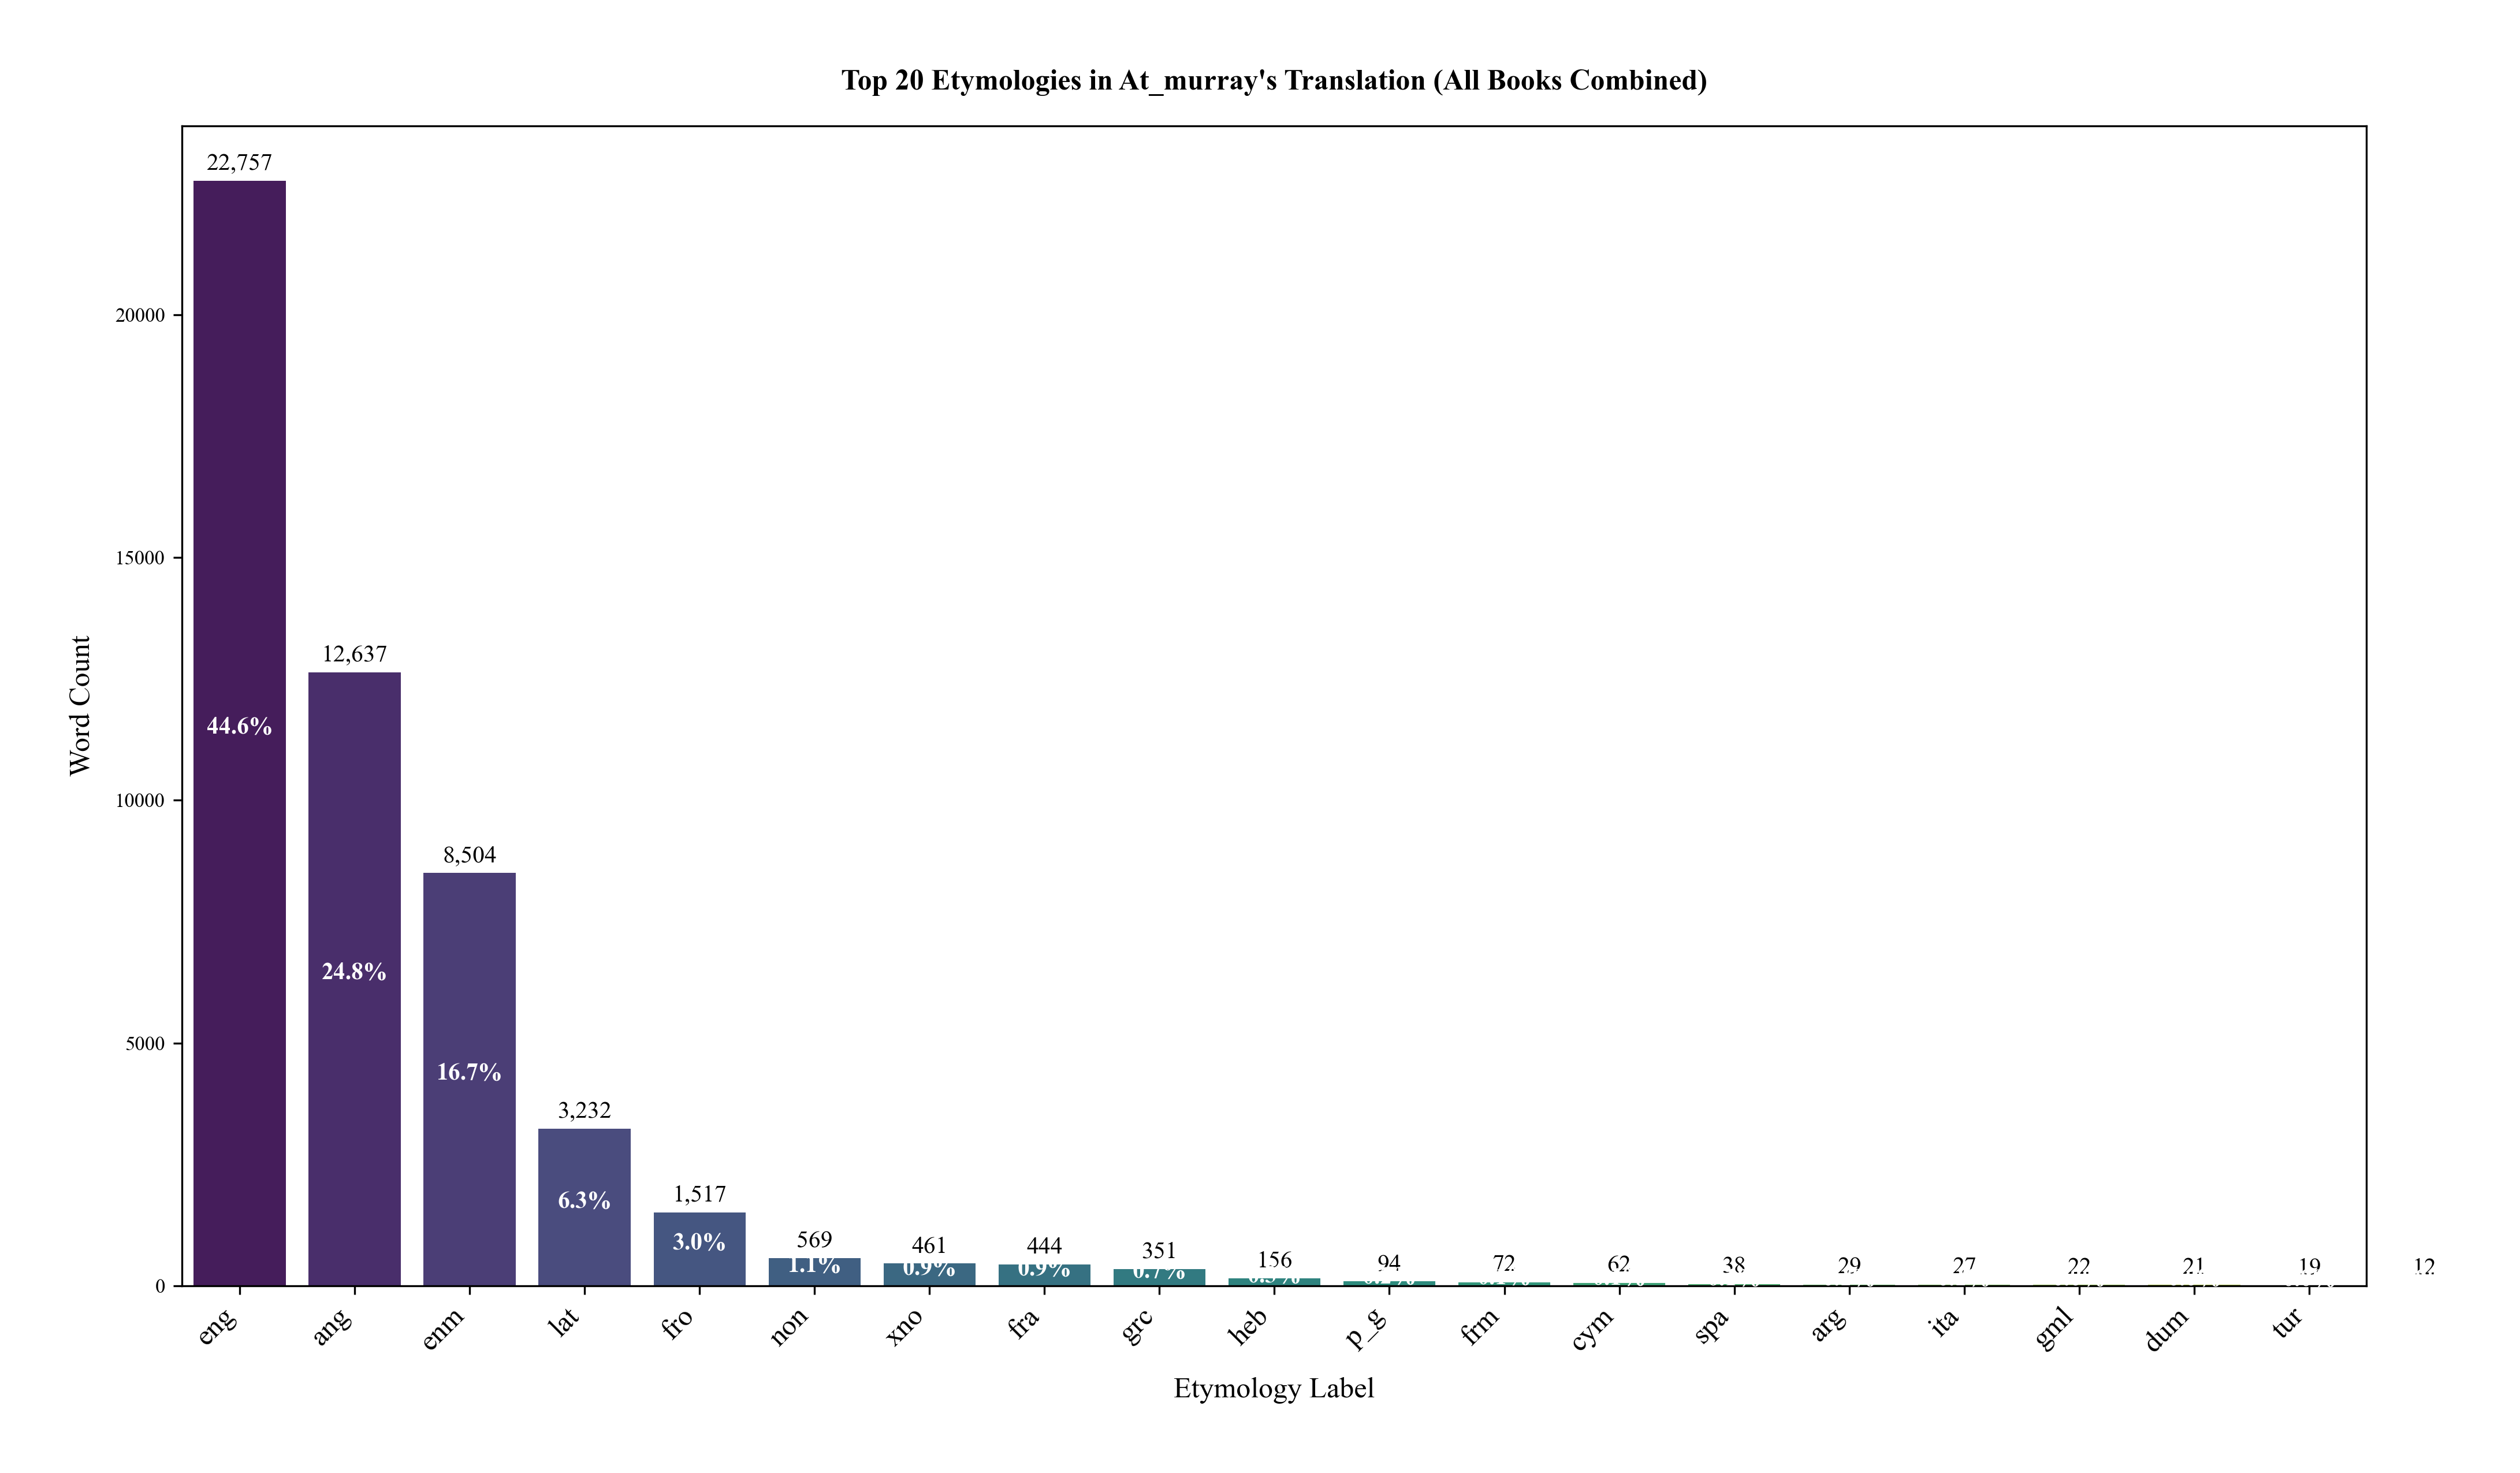

Total words analyzed: 51,073
Number of distinct etymologies: 33
Percentage of words from top 3 etymologies: 85.95%


In [13]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter

def plot_aggregated_etymologies(df, translator_name='murray', top_n=20):
    """
    Aggregate etymology counts across all books for a specific translator
    and plot the top N most frequent etymologies.
    
    Parameters:
    df (DataFrame): The DataFrame containing the data
    translator_name (str): The name of the translator to filter by
    top_n (int): Number of top etymologies to display
    """
    # Filter for the specific translator
    translator_data = df[df['translator'] == translator_name]
    
    if len(translator_data) == 0:
        print(f"No data found for translator: {translator_name}")
        print(f"Available translators: {df['translator'].unique()}")
        return
    
    # Aggregate counts across all books
    aggregated_counts = Counter()
    
    for _, row in translator_data.iterrows():
        ety_counts = row['ety_label_counts']
        aggregated_counts.update(ety_counts)
    
    # Convert the aggregated counter to a DataFrame
    agg_df = pd.DataFrame(list(aggregated_counts.items()), columns=['Etymology', 'Count'])
    
    # Sort by count in descending order and get top N
    agg_df = agg_df.sort_values('Count', ascending=False).head(top_n)
    
    # Create the plot
    plt.figure(figsize=(14, 8))
    bar_plot = sns.barplot(x='Etymology', y='Count', data=agg_df, palette='viridis')
    
    # Customize the plot
    plt.title(f'Top {top_n} Etymologies in {translator_name.capitalize()}\'s Translation (All Books Combined)')
    plt.xlabel('Etymology Label')
    plt.ylabel('Word Count')
    plt.xticks(rotation=45, ha='right')
    
    # Add count labels on top of bars
    for i, v in enumerate(agg_df['Count']):
        plt.text(i, v + (max(agg_df['Count']) * 0.01), f'{v:,}', ha='center')
    
    # Add percentage labels
    total_words = agg_df['Count'].sum()
    for i, v in enumerate(agg_df['Count']):
        percentage = (v / total_words) * 100
        plt.text(i, v/2, f'{percentage:.1f}%', ha='center', color='white', fontweight='bold')
    
    plt.tight_layout()
    plt.show()
    
    return aggregated_counts

# Example usage
aggregated_counts = plot_aggregated_etymologies(at_murray, translator_name='AT_Murray', top_n=20)

# Optional: Print the total number of words analyzed
if aggregated_counts:
    total_words = sum(aggregated_counts.values())
    print(f"Total words analyzed: {total_words:,}")
    
    # Calculate and display etymology diversity metrics
    print(f"Number of distinct etymologies: {len(aggregated_counts)}")
    
    # Calculate percentage of words from the top 3 etymologies
    top_3 = sum(count for _, count in aggregated_counts.most_common(3))
    print(f"Percentage of words from top 3 etymologies: {(top_3/total_words)*100:.2f}%")